In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

/tmp/ipykernel_5257/104838516.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_mag = pd.read_csv(


iden   mag      mag_err    SFR      SFR_err
 101   22.017     0.001    0.145    0.386
 151   20.471     0.384    0.831    0.185
 202   19.614     0.096    4.694    0.109
 212   19.267     0.222    3.646    0.107
 285   20.507     0.094    0.516    0.770
 407   20.188     0.206    3.063    0.093
 459   21.324     0.441    0.588    0.253
 553   19.653     0.090    2.422    0.137
 590   20.030     0.152    3.096    0.080
 680   21.169     0.269    1.057    0.120
 812   18.846     0.128    4.543    0.286
1081   22.605     0.437    0.394    0.175
1086   22.817     0.345    0.419    0.132
1103   22.439     0.430    0.531    0.184
1233   20.613     0.223    0.236    0.594


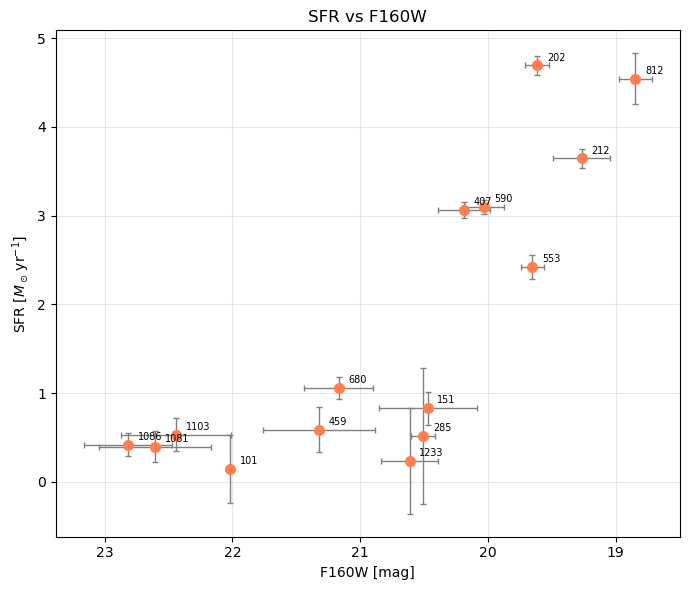

iden   mag      mag_err    SFR      SFR_err
 101   22.497     0.001    0.145    0.386
 151   20.690     0.016    0.831    0.185
 202   20.068     0.011    4.694    0.109
 212   19.980     0.091    3.646    0.107
 285   20.967     0.013    0.516    0.770
 407   20.568     0.049    3.063    0.093
 459   21.548     0.030    0.588    0.253
 553   20.178     0.012    2.422    0.137
 590   20.608     0.015    3.096    0.080
 680   21.745     0.016    1.057    0.120
 812   19.947     0.064    4.543    0.286
1081   22.761     0.173    0.394    0.175
1086   22.932     0.131    0.419    0.132
1103   22.686     0.028    0.531    0.184
1233   21.387     0.015    0.236    0.594


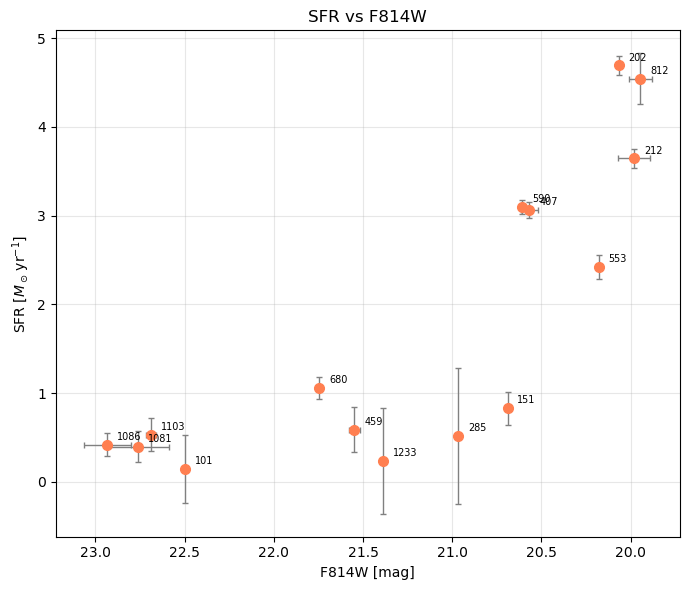

In [22]:


# ----------------------------
# Load combined.csv
# ----------------------------
df_sfr = pd.read_csv("LINES_FITS/combined.csv")

# Select row with maximum SFR for each object
df_sfr_sel = df_sfr.loc[df_sfr.groupby("iden")["SFR"].idxmax()]

# Keep only needed columns
df_sfr_sel = df_sfr_sel[["iden", "SFR", "d_SFR"]]

# ----------------------------
# Load magnitude catalog
# ----------------------------
cat_path = "2my_galaxies_catalog-Copy1.cat"

df_mag = pd.read_csv(
    cat_path,
    delim_whitespace=True,
    comment="#"
)

# Replace invalid values
df_mag.replace(99.99, np.nan, inplace=True)

# Keep only relevant columns
df_mag = df_mag[
    ["iden",
     "F814W", "F814W_err",
     "F160W", "F160W_err"]
]

# ----------------------------
# Merge catalogs
# ----------------------------
df = pd.merge(df_sfr_sel, df_mag, on="iden", how="inner")




# ----------------------------
# Plot function
# ----------------------------
def plot_sfr_vs_mag(mag, mag_err, mag_label, filename):
    mask = df[mag].notna()

    x = df.loc[mask, mag]
    xerr = df.loc[mask, mag_err]
    y = df.loc[mask, "SFR"]
    yerr = df.loc[mask, "d_SFR"]
    labels = df.loc[mask, "iden"]

    # print values for sanity check
    print("iden   mag      mag_err    SFR      SFR_err")

    for lab, xi, xei, yi, yei in zip(labels, x, xerr, y, yerr):
        print(f"{lab:4d}  {xi:7.3f}  {xei:8.3f}  {yi:7.3f}  {yei:7.3f}")


    
    plt.figure(figsize=(7, 6))

    plt.errorbar(
        x, y,
        color="coral",
        xerr=xerr,
        yerr=yerr,
        fmt='o',
        ecolor = "gray",
        capsize=2,
        elinewidth=1,
        markersize=7
    )

    for xi, yi, lab in zip(x, y, labels):
        plt.annotate(str(lab),
                 xy=(xi, yi),
                 xytext=(7, 2),
                 textcoords='offset points',
                 fontsize=7,
                 ha='left',
                 va='bottom')


    plt.xlabel(f"{mag_label} [mag]")
    plt.ylabel("SFR [$M_\\odot\\,\\mathrm{yr}^{-1}$]")
    plt.title(f"SFR vs {mag_label}")

    # Astronomical convention: brighter = left
    plt.gca().invert_xaxis()

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# ----------------------------
# Make plots
# ----------------------------
plot_sfr_vs_mag(
    mag="F160W",
    mag_err="F160W_err",
    mag_label="F160W",
    filename="SFR_vs_F160W.png"
)

plot_sfr_vs_mag(
    mag="F814W",
    mag_err="F814W_err",
    mag_label="F814W",
    filename="SFR_vs_F814W.png"
)



<>:86: SyntaxWarning: invalid escape sequence '\l'
<>:86: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_5257/1805528758.py:86: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel("12 + $\log_{10}$(O/H)")
/tmp/ipykernel_5257/1805528758.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_mag = pd.read_csv(


iden   mag     mag_err  12+log(O/H) 12+log(O/H)_err
 101   22.017     0.001    8.685    0.048
 151   20.471     0.384    8.441    0.028
 202   19.614     0.096    8.697    0.019
 212   19.267     0.222    8.577    0.016
 285   20.507     0.094    8.732    0.087
 407   20.188     0.206    8.549    0.011
 459   21.324     0.441    8.439    0.030
 553   19.653     0.090    8.701    0.027
 590   20.030     0.152    8.664    0.014
 680   21.169     0.269    8.419    0.017
 812   18.846     0.128    8.610    0.024
1081   22.605     0.437    8.256    0.073
1086   22.817     0.345    8.215    0.046
1103   22.439     0.430    8.274    0.059
1233   20.613     0.223    8.600    0.049


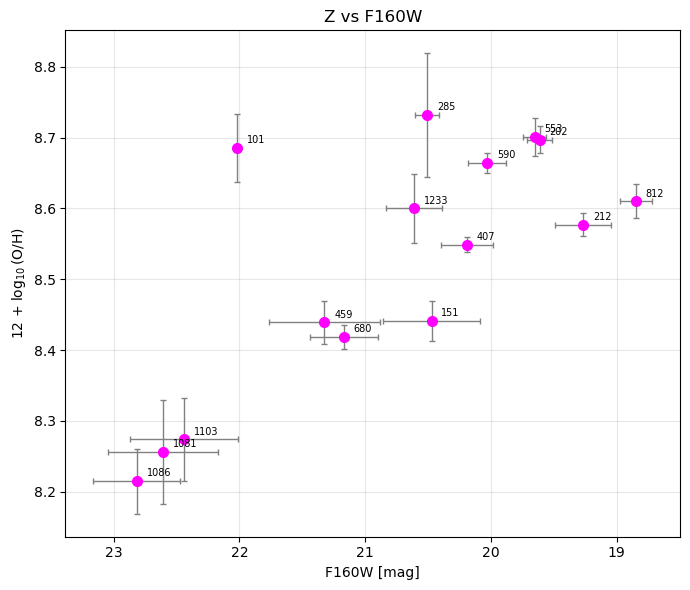

iden   mag     mag_err  12+log(O/H) 12+log(O/H)_err
 101   22.497     0.001    8.685    0.048
 151   20.690     0.016    8.441    0.028
 202   20.068     0.011    8.697    0.019
 212   19.980     0.091    8.577    0.016
 285   20.967     0.013    8.732    0.087
 407   20.568     0.049    8.549    0.011
 459   21.548     0.030    8.439    0.030
 553   20.178     0.012    8.701    0.027
 590   20.608     0.015    8.664    0.014
 680   21.745     0.016    8.419    0.017
 812   19.947     0.064    8.610    0.024
1081   22.761     0.173    8.256    0.073
1086   22.932     0.131    8.215    0.046
1103   22.686     0.028    8.274    0.059
1233   21.387     0.015    8.600    0.049


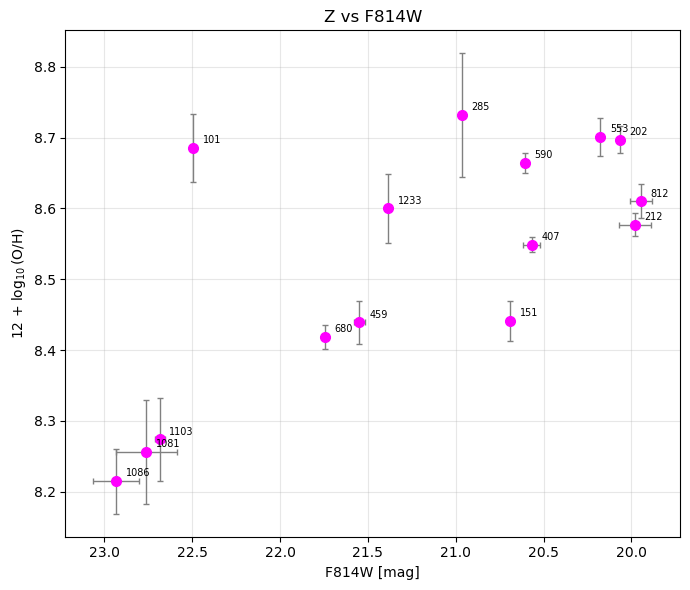

In [24]:


# ----------------------------
# Load combined.csv
# ----------------------------
df_sfr = pd.read_csv("LINES_FITS/combined.csv")

# Select row with maximum SFR for each object
df_sfr_sel = df_sfr.loc[df_sfr.groupby("iden")["SFR"].idxmax()]

# Keep only needed columns
df_sfr_sel = df_sfr_sel[["iden", "12+log(O/H)", "12+log(O/H)_err"]]

# ----------------------------
# Load magnitude catalog
# ----------------------------
cat_path = "2my_galaxies_catalog-Copy1.cat"

df_mag = pd.read_csv(
    cat_path,
    delim_whitespace=True,
    comment="#"
)

# Replace invalid values
df_mag.replace(99.99, np.nan, inplace=True)

# Keep only relevant columns
df_mag = df_mag[
    ["iden",
     "F814W", "F814W_err",
     "F160W", "F160W_err"]
]

# ----------------------------
# Merge catalogs
# ----------------------------
df = pd.merge(df_sfr_sel, df_mag, on="iden", how="inner")




# ----------------------------
# Plot function
# ----------------------------
def plot_z_vs_mag(mag, mag_err, mag_label, filename):
    mask = df[mag].notna()

    x = df.loc[mask, mag]
    xerr = df.loc[mask, mag_err]
    y = df.loc[mask, "12+log(O/H)"]
    yerr = df.loc[mask, "12+log(O/H)_err"]
    labels = df.loc[mask, "iden"]

    # print values for sanity check
    print("iden   mag     mag_err  12+log(O/H) 12+log(O/H)_err")

    for lab, xi, xei, yi, yei in zip(labels, x, xerr, y, yerr):
        print(f"{lab:4d}  {xi:7.3f}  {xei:8.3f}  {yi:7.3f}  {yei:7.3f}")


    
    plt.figure(figsize=(7, 6))

    plt.errorbar(
        x, y,
        color="magenta",
        xerr=xerr,
        yerr=yerr,
        fmt='o',
        ecolor = "gray",
        capsize=2,
        elinewidth=1,
        markersize=7
    )

    for xi, yi, lab in zip(x, y, labels):
        plt.annotate(str(lab),
                 xy=(xi, yi),
                 xytext=(7, 2),
                 textcoords='offset points',
                 fontsize=7,
                 ha='left',
                 va='bottom')


    plt.xlabel(f"{mag_label} [mag]")
    plt.ylabel("12 + $\log_{10}$(O/H)")
    plt.title(f"Z vs {mag_label}")

    # Astronomical convention: brighter = left
    plt.gca().invert_xaxis()

    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    plt.savefig(filename, dpi=300, bbox_inches="tight")
    plt.show()


# ----------------------------
# Make plots
# ----------------------------
plot_z_vs_mag(
    mag="F160W",
    mag_err="F160W_err",
    mag_label="F160W",
    filename="Z_vs_F160W.png"
)

plot_z_vs_mag(
    mag="F814W",
    mag_err="F814W_err",
    mag_label="F814W",
    filename="Z_vs_F814W.png"
)



iden   logM      logSFR    logSFR_err_up logSFR_err_low SFR
 101    9.140    -0.839       0.142         0.212     0.145
 151    9.890    -0.080       0.074         0.089     0.831
 202   10.160     0.672       0.045         0.050     4.695
 212   10.280     0.562       0.044         0.049     3.647
 285    9.890    -0.287       0.248         0.638     0.516
 407    9.860     0.486       0.039         0.043     3.063
 459    9.440    -0.231       0.098         0.127     0.588
 553   10.230     0.384       0.056         0.064     2.422
 590   10.230     0.491       0.033         0.036     3.096
 680    9.760     0.024       0.049         0.055     1.057
 812   10.550     0.657       0.109         0.146     4.543
1081    8.780    -0.405       0.070         0.083     0.394
1086    8.670    -0.377       0.054         0.061     0.419
1103    8.990    -0.275       0.073         0.088     0.531
1233   10.090    -0.626       0.203         0.392     0.236
1483   10.460    -2.298       0.186     

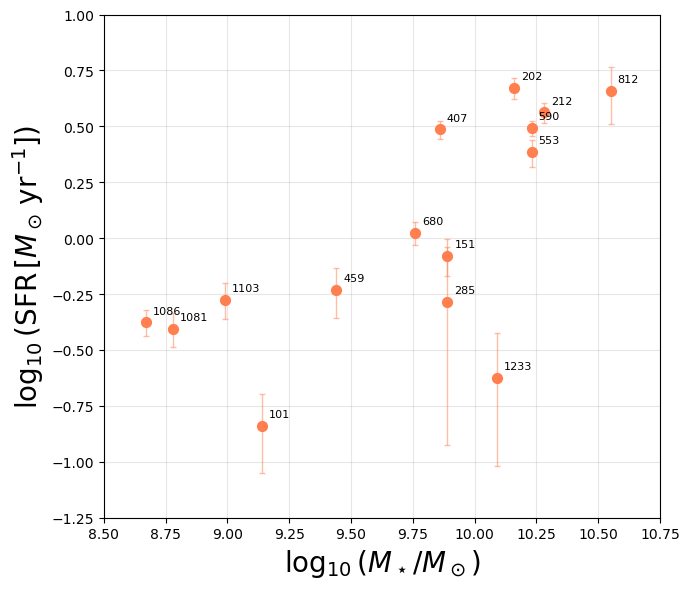

In [16]:
# values for 101 and 1233 are estimations based on Av=[0,3]
# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("LINES_FITS/new_flag_combined.csv")

# Select row with maximum SFR per object
df_sel = df.loc[
    df[ (~df["flag_Ha_SN"])
    ]
    .groupby("iden")["SFR"]
    .idxmax()
]

# ----------------------------
# Extract values
# ----------------------------
x = df_sel["logM"]
y = df_sel["log10_SFR"]
yerr_up = df_sel["d_log10_SFR_up"]
yerr_low = df_sel["d_log10_SFR_low"]
labels = df_sel["iden"]
sfr = df_sel["SFR"]


# print values for sanity check
print("iden   logM      logSFR    logSFR_err_up logSFR_err_low SFR")

for lab, xi, yi, ye_up, ye_low, sfr_val in zip(
        labels, x, y, yerr_up, yerr_low, sfr):

    print(f"{lab:4d}  "
          f"{xi:7.3f}  "
          f"{yi:8.3f}  "
          f"{ye_up:10.3f}  "
          f"{ye_low:12.3f}  "
          f"{sfr_val:8.3f}")

#coeffs = np.polyfit(x, y, 1, 
                    #w=1/yerr
#                   )
#slope, intercept = coeffs
#xfit = np.linspace(x.min(), x.max(), 100)
#yfit = slope * xfit + intercept

#print(f"Slope = {slope:.3f}, Intercept = {intercept:.3f}")
# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(7, 6))
plt.scatter(x, y, color="coral", s=50, zorder=3)
#plt.plot(xfit, yfit, linestyle='--', linewidth=2, alpha=0.5, color="orange", label='Linear fit')
plt.errorbar(
    x, y,
    yerr=[yerr_low, yerr_up],
    fmt='none',
    color = "coral",
    alpha=.5,
    capsize=2,
    elinewidth=1,
    markersize=7
    )
# Label points
for xi, yi, lab in zip(x, y, labels):
    plt.annotate(
        str(lab),
        xy=(xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom"
    )

# ----------------------------
# Plot formatting
# ----------------------------
plt.xlabel(r'$\log_{10}(M_\star / M_\odot)$', fontsize=20)
plt.ylabel(r'$\log_{10}(\mathrm{SFR}\,[M_\odot\,\mathrm{yr}^{-1}])$', fontsize=20)
#plt.title('SFR-Mass Relation')
plt.ylim(-1.25, 1)
plt.xlim(8.5,10.75)

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig("logSFR_vs_logM.png", dpi=300, bbox_inches="tight")
plt.show()



Fit including intrinsic scatter:
Slope          = 0.312
Intercept      = -3.138
Intrinsic σ_int = 0.727 dex
Reduced χ²     = 1.000

Weighted fit:
Slope     = 0.593
Intercept = -5.533


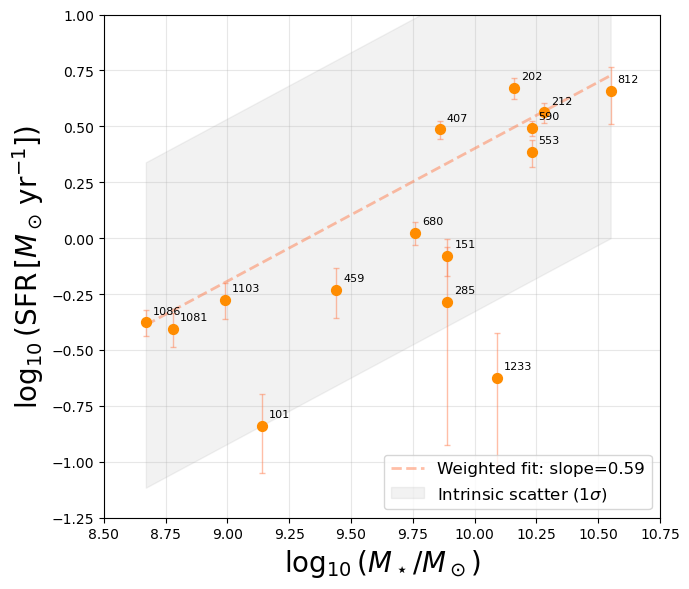

In [26]:
from scipy.optimize import brentq

# ----------------------------
# Build symmetric errors
# ----------------------------
# Use mean of upper/lower errors
yerr_sym = 0.5 * (yerr_up + yerr_low)

# Remove possible zero or NaN errors
mask = np.isfinite(yerr_sym) & (yerr_sym > 0)

x_fit = x[mask].values
y_fit = y[mask].values
sigma_obs = yerr_sym[mask].values


def fit_with_intrinsic_scatter(sigma_int):

    sigma_tot = np.sqrt(sigma_obs**2 + sigma_int**2)
    weights = 1.0 / sigma_tot**2

    coeffs = np.polyfit(x_fit, y_fit, 1, w=weights)
    slope, intercept = coeffs

    model = slope * x_fit + intercept
    chi2 = np.sum(((y_fit - model) / sigma_tot)**2)

    dof = len(x_fit) - 2
    chi2_red = chi2 / dof

    return chi2_red, slope, intercept




def objective(sigma_int):
    chi2_red, _, _ = fit_with_intrinsic_scatter(sigma_int)
    return chi2_red - 1.0

# Search between 0 and 1 dex (reasonable for SFR–M relation)
sigma_int = brentq(objective, 0.0, 1.0)

chi2_red, slope, intercept = fit_with_intrinsic_scatter(sigma_int)

print("\nFit including intrinsic scatter:")
print(f"Slope          = {slope:.3f}")
print(f"Intercept      = {intercept:.3f}")
print(f"Intrinsic σ_int = {sigma_int:.3f} dex")
print(f"Reduced χ²     = {chi2_red:.3f}")



# ----------------------------
# Weighted linear regression
# ----------------------------
weights = 1.0 / sigma**2

coeffs = np.polyfit(x_fit, y_fit, 1, w=weights)
slope, intercept = coeffs

# For plotting
xline = np.linspace(x.min(), x.max(), 200)
yline = slope * xline + intercept

print(f"\nWeighted fit:")
print(f"Slope     = {slope:.3f}")
print(f"Intercept = {intercept:.3f}")



plt.figure(figsize=(7, 6))
plt.scatter(x, y, color="darkorange", s=50, zorder=3)
plt.plot(
    xline, yline,
    linestyle='--',
    linewidth=2,
    color="coral",
    alpha=0.5,
    label=f'Weighted fit: slope={slope:.2f}'
)

plt.fill_between(
    xline,
    yline - sigma_int,
    yline + sigma_int,
    color="gray",
    alpha=0.1,
    label=r"Intrinsic scatter ($1\sigma$)"
)

plt.errorbar(
    x, y,
    yerr=[yerr_low, yerr_up],
    fmt='none',
    color = "coral",
    alpha=.5,
    capsize=2,
    elinewidth=1,
    markersize=7
    )
# Label points
for xi, yi, lab in zip(x, y, labels):
    plt.annotate(
        str(lab),
        xy=(xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom"
    )

# ----------------------------
# Plot formatting
# ----------------------------
plt.xlabel(r'$\log_{10}(M_\star / M_\odot)$', fontsize=20)
plt.ylabel(r'$\log_{10}(\mathrm{SFR}\,[M_\odot\,\mathrm{yr}^{-1}])$', fontsize=20)
#plt.title('SFR-Mass Relation')
plt.ylim(-1.25, 1)
plt.xlim(8.5,10.75)

plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.legend(fontsize=12)

iden     logM         Z       Z_err 
 101    9.140     8.685       0.048
 151    9.860     8.441       0.028
 202   10.160     8.697       0.019
 212   10.280     8.577       0.016
 285    9.890     8.732       0.087
 407    9.860     8.549       0.011
 459    9.440     8.439       0.030
 553   10.230     8.701       0.027
 590   10.230     8.664       0.014
 680    9.760     8.419       0.017
 812   10.550     8.610       0.024
1081    8.780     8.256       0.073
1086    8.670     8.215       0.046
1103    8.990     8.274       0.059
1233   10.090     8.600       0.049


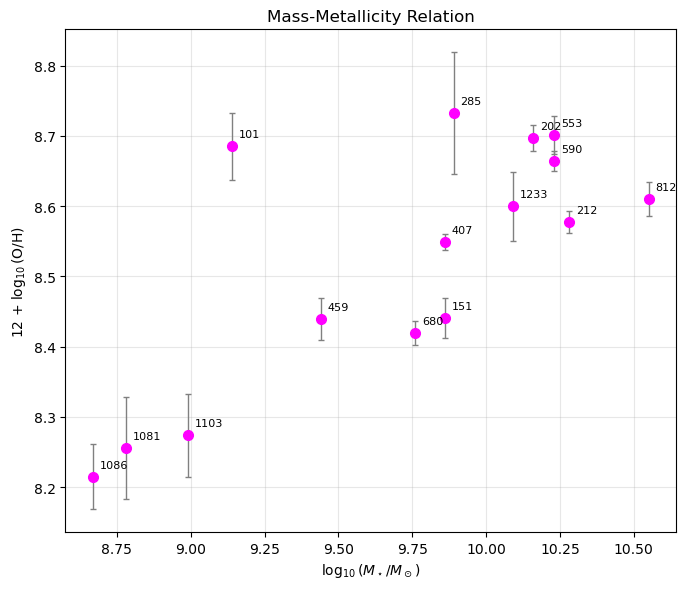

In [46]:

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("LINES_FITS/combined.csv")

# Select row with maximum SFR per object
df_sel = df.loc[df.groupby("iden")["SFR"].idxmax()]

# ----------------------------
# Extract values
# ----------------------------
x = df_sel["logM"]
y = df_sel["12+log(O/H)"]
yerr = df_sel["12+log(O/H)_err"]
labels = df_sel["iden"]


# print values for sanity check
print("iden     logM         Z       Z_err ")

for lab, xi, yi, yei  in zip(labels, x, y, yerr):
    print(f"{lab:4d}  {xi:7.3f}  {yi:8.3f}  {yei:10.3f}")

# ----------------------------
# Plot
# ----------------------------
plt.figure(figsize=(7, 6))

plt.errorbar(
    x, y,
    color="magenta",
    yerr=yerr,
    fmt='o',
    ecolor = "gray",
    capsize=2,
    elinewidth=1,
    markersize=7
    )
# Label points
for xi, yi, lab in zip(x, y, labels):
    plt.annotate(
        str(lab),
        xy=(xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom"
    )

# ----------------------------
# Plot formatting
# ----------------------------
plt.xlabel(r'$\log_{10}(M_\star / M_\odot)$')
plt.ylabel(r'12 + $\log_{10}$(O/H)')
plt.title('Mass-Metallicity Relation')

plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig("mass_metal_relation.png", dpi=300, bbox_inches="tight")
plt.show()


iden   logM      logSFR    logSFR_err_up logSFR_err_low SFR
 101    9.140    -0.979       0.142         0.212     0.145
 151    9.890    -0.970       0.074         0.089     0.831
 202   10.160    -0.488       0.045         0.050     4.695
 212   10.280    -0.718       0.044         0.049     3.647
 285    9.890    -1.177       0.248         0.638     0.516
 407    9.860    -0.374       0.039         0.043     3.063
 459    9.440    -0.671       0.098         0.127     0.588
 553   10.230    -0.846       0.056         0.064     2.422
 590   10.230    -0.739       0.033         0.036     3.096
 680    9.760    -0.736       0.049         0.055     1.057
 812   10.550    -0.893       0.109         0.146     4.543
1081    8.780    -0.185       0.070         0.083     0.394
1086    8.670    -0.047       0.054         0.061     0.419
1103    8.990    -0.265       0.073         0.088     0.531
1233   10.090    -1.716       0.203         0.392     0.236
1483   10.460    -3.758       0.186     

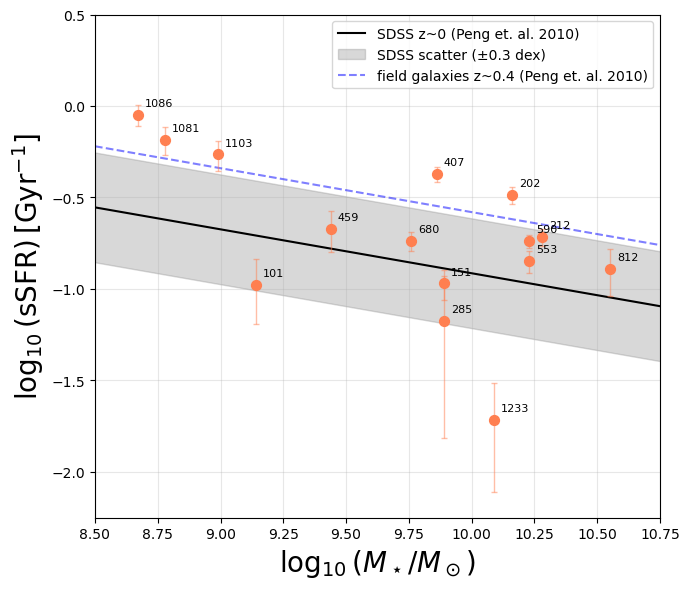

In [32]:

# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("LINES_FITS/new_flag_combined.csv")

# Select row with maximum SFR per object
df_sel = df.loc[
    df[ (~df["flag_Ha_SN"])
    ]
    .groupby("iden")["SFR"]
    .idxmax()
]
# ----------------------------
# Extract values
# ----------------------------
x = df_sel["logM"]
y = df_sel["log10_SFR"]
yerr_up = df_sel["d_log10_SFR_up"]
yerr_low = df_sel["d_log10_SFR_low"]
labels = df_sel["iden"]
sfr = df_sel["SFR"]

# compute log sSFR
df_sel["logsSFR"] = df["log10_SFR"] - df["logM"] + 9
y = df_sel["logsSFR"]

# SDSS relation
logM_sdss = np.linspace(8.5, 11.2, 200)
log_sSFR_sdss = 1.486 - 0.24 * logM_sdss     # sloan, field galaxies z=0

logSSFR = 1.820 - 0.24 * logM_sdss # dashed line, field galaxies at z=0.38




# print values for sanity check
print("iden   logM      logSFR    logSFR_err_up logSFR_err_low SFR")

for lab, xi, yi, ye_up, ye_low, sfr_val in zip(
        labels, x, y, yerr_up, yerr_low, sfr):

    print(f"{lab:4d}  "
          f"{xi:7.3f}  "
          f"{yi:8.3f}  "
          f"{ye_up:10.3f}  "
          f"{ye_low:12.3f}  "
          f"{sfr_val:8.3f}")


plt.figure(figsize=(7,6))

# data
plt.scatter(x, y, color="coral", s=50, zorder=3)

# SDSS relation + scatter
plt.plot(logM_sdss, log_sSFR_sdss, color="black", label="SDSS z~0 (Peng et. al. 2010)")
plt.fill_between(
    logM_sdss,
    log_sSFR_sdss - 0.3,
    log_sSFR_sdss + 0.3,
    color="gray",
    alpha=0.3,
    label="SDSS scatter (±0.3 dex)"
)
plt.plot(logM_sdss, logSSFR, color="blue", linestyle="--", alpha=0.5, label="field galaxies z~0.4 (Peng et. al. 2010)")

plt.errorbar(
     x, y,
    yerr=[yerr_low, yerr_up],
    fmt='none',
    ecolor = "coral",
    alpha = 0.5,
    capsize=2,
    elinewidth=1,
   markersize=7
    )

# Label points
for xi, yi, lab in zip(x, y, labels):
    plt.annotate(
        str(lab),
        xy=(xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom"
    )


plt.xlabel(r'$\log_{10}(M_\star / M_\odot)$', fontsize=20)
plt.ylabel(r"$\log_{10}(\mathrm{sSFR})\,[\mathrm{Gyr}^{-1}]$", fontsize=20)
#plt.title("sSFR-Mass Relation")
plt.ylim(-2.25, 0.5)
plt.xlim(8.5,10.75)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig("sSFR_Peng.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()


iden     logM       Z          Zerr
 101    9.140    8.685       0.048
 151    9.890    8.441       0.028
 202   10.160    8.697       0.019
 212   10.280    8.577       0.016
 285    9.890    8.732       0.087
 407    9.860    8.549       0.011
 459    9.440    8.439       0.030
 553   10.230    8.701       0.027
 590   10.230    8.664       0.014
 680    9.760    8.419       0.017
 812   10.550    8.610       0.024
1081    8.780    8.256       0.073
1086    8.670    8.215       0.046
1103    8.990    8.274       0.059
1233   10.090    8.600       0.049
1483   10.460    8.692       0.052


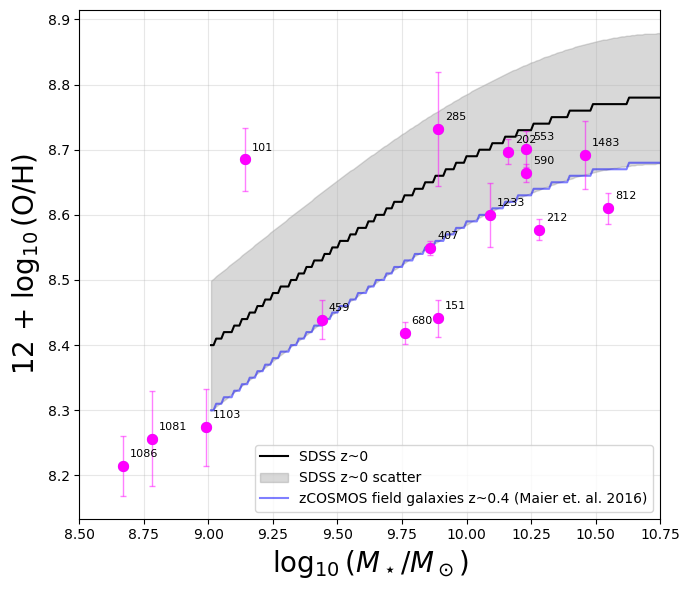

In [34]:
# add datapoints for Z-0.1 --> z=0.38


# --- read SDSS mass-metallicity relation ---
sdss = pd.read_csv(
    "SDSS_OH.txt",
    sep=r"\s+",
    comment="#",
    names=["logM", "oh", "ohlow", "ohhigh", "ohEvol"]
)

sdss_offset = sdss["oh"]-0.1
# ----------------------------
# Load data
# ----------------------------
df = pd.read_csv("LINES_FITS/new_flag_combined.csv")

# Select row with maximum SFR per object
df_sel = df.loc[df.groupby("iden")["SFR"].idxmax()]

# ----------------------------
# Extract values
# ----------------------------
x = df_sel["logM"]
y = df_sel["12+log(O/H)"]
yerr = df_sel["12+log(O/H)_err"]
labels = df_sel["iden"]
y_shift = y - 0.1


# print values for sanity check
print("iden     logM       Z          Zerr")

for lab, xi, yi, yei  in zip(labels, x, y, yerr):
    print(f"{lab:4d}  {xi:7.3f} {yi:8.3f}  {yei:10.3f}")


    

plt.figure(figsize=(7,6))

# data
plt.scatter(x, y, color="magenta", s=50, zorder=3)


# SDSS relation + scatter
plt.plot(sdss["logM"], sdss["oh"], color="black", label="SDSS z~0")
plt.fill_between(
    sdss["logM"],
    sdss["ohlow"],
    sdss["ohhigh"],
    color="gray",
    alpha=0.3,
    label="SDSS z~0 scatter"
)

plt.plot(sdss["logM"], sdss_offset, color="blue", alpha=0.5, label="zCOSMOS field galaxies z~0.4 (Maier et. al. 2016)")



plt.errorbar(
    x, y,
    yerr=yerr,
    fmt='o',
    ecolor = "magenta",
    alpha=0.5,
    capsize=2,
    elinewidth=1,
   markersize=7
    )

#plt.errorbar(
#    x, y_shift,
#    yerr=yerr,
#    fmt='s',
#    color="lightpink",
#    ecolor="gray",
#    capsize=2,
#    elinewidth=1,
#    markersize=5
#)
# Label points
for xi, yi, lab in zip(x, y, labels):
    plt.annotate(
        str(lab),
        xy=(xi, yi),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8,
        ha="left",
        va="bottom"
    )

    
plt.xlabel(r'$\log_{10}(M_\star / M_\odot)$', fontsize=20)
plt.ylabel(r'12 + $\log_{10}$(O/H)', fontsize=20)
#plt.title("local SDSS Mass-Metallicity Relation")
plt.xlim(8.5, 10.75)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig("Mass-Metal_local_2.png", dpi=300, bbox_inches="tight")
plt.show()
plt.show()
